# Notebook 04: Comprehensive Classical Machine Learning Benchmarking (8 Baselines + Ensemble)
## Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms

This notebook implements, benchmarks, and rigorously evaluates **8 distinct classical machine learning architectures** alongside a **High-Performance Stacking Ensemble** on 196 electrophysiological domain features extracted from multi-lead ECGs:
1. **Logistic Regression (L2 Regularized)**
2. **Random Forest Classifier (Bagged Decision Trees)**
3. **Extra Trees Classifier (Extremely Randomized Trees)**
4. **LightGBM Classifier (Histogram-based GBDT)**
5. **XGBoost Classifier (Gradient Boosted Trees)**
6. **Support Vector Machine (Calibrated Linear SVC)**
7. **K-Nearest Neighbors (Distance-Weighted KNN)**
8. **Multi-Layer Perceptron (MLP Neural Network)**
9. **Supervised Stacking / Soft-Voting Ensemble (Targeting $\ge 95\%$ Accuracy)**

All models are evaluated on the identical patient-level held-out test split ($N=525$) across Macro/Micro AUROC, Macro/Micro F1, Macro AUPRC, Multi-Label Accuracy ($1 - \text{Hamming Loss}$), and per-class diagnostic accuracy.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    hamming_loss, accuracy_score
)
import lightgbm as lgb
import xgboost as xgb

# Plotting config
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 300
})

RESULTS_DIR = r"C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TAB_DIR = os.path.join(RESULTS_DIR, "tables")
MET_DIR = os.path.join(RESULTS_DIR, "metrics")

for d in [FIG_DIR, TAB_DIR, MET_DIR]:
    os.makedirs(d, exist_ok=True)

print("Expanded 8-Baseline ML environment initialized successfully.")


Expanded 8-Baseline ML environment initialized successfully.


In [2]:
data = np.load(os.path.join(MET_DIR, "preprocessed_data.npz"))
X_train = data['X_train'] # (N_train, 12, 1000)
y_train = data['y_train'] # (N_train, 9)
X_val   = data['X_val']   # (N_val, 12, 1000)
y_val   = data['y_val']   # (N_val, 9)
X_test  = data['X_test']  # (N_test, 12, 1000)
y_test  = data['y_test']  # (N_test, 9)
target_classes = list(data['target_classes'])

print(f"Loaded Preprocessed Data:")
print(f"  Train: X={X_train.shape}, y={y_train.shape}")
print(f"  Val:   X={X_val.shape}, y={y_val.shape}")
print(f"  Test:  X={X_test.shape}, y={y_test.shape}")
print(f"  Classes ({len(target_classes)}): {', '.join(target_classes)}")


Loaded Preprocessed Data:
  Train: X=(2450, 12, 1000), y=(2450, 9)
  Val:   X=(525, 12, 1000), y=(525, 9)
  Test:  X=(525, 12, 1000), y=(525, 9)
  Classes (9): SR, AF, IAVB, LBBB, RBBB, PAC, PVC, STD, STE


In [3]:
def extract_comprehensive_ecg_features(X, fs=100.0):
    '''
    Extract 196 electrophysiological domain features:
    - Time-domain statistics across 12 leads (mean, std, ptp, rms, zcr, skew, kurtosis, q25, q75, iqr) = 120 feats
    - Frequency-domain band powers (delta, theta, alpha, beta, gamma, spectral entropy) across 12 leads = 72 feats
    - Lead II heart rate variability metrics (RMSSD, pNN50) = 2 feats
    - Frontal plane lead cross-correlations (I-II, II-III) = 2 feats
    Total = 196 features.
    '''
    N, L, T = X.shape
    
    # 1. Time-Domain Moments per Lead (N, 12)
    mean_v = np.mean(X, axis=-1)
    std_v  = np.std(X, axis=-1)
    p2p_v  = np.ptp(X, axis=-1)
    rms_v  = np.sqrt(np.mean(X**2, axis=-1))
    zcr_v  = ((X[:, :, :-1] * X[:, :, 1:]) < 0).sum(axis=-1) / float(T)
    skew_v = stats.skew(X, axis=-1)
    kurt_v = stats.kurtosis(X, axis=-1)
    q25_v  = np.percentile(X, 25, axis=-1)
    q75_v  = np.percentile(X, 75, axis=-1)
    iqr_v  = q75_v - q25_v
    
    # 2. Spectral FFT Bandpowers per Lead (N, 12)
    freqs = np.fft.rfftfreq(T, d=1.0/fs)
    psd = np.abs(np.fft.rfft(X, axis=-1))**2
    psd_norm = psd / (np.sum(psd, axis=-1, keepdims=True) + 1e-12)
    
    delta = np.sum(psd[:, :, (freqs >= 0.5) & (freqs < 4)], axis=-1)
    theta = np.sum(psd[:, :, (freqs >= 4) & (freqs < 8)], axis=-1)
    alpha = np.sum(psd[:, :, (freqs >= 8) & (freqs < 13)], axis=-1)
    beta  = np.sum(psd[:, :, (freqs >= 13) & (freqs < 30)], axis=-1)
    gamma = np.sum(psd[:, :, (freqs >= 30) & (freqs <= 45)], axis=-1)
    
    p_safe = np.clip(psd_norm, 1e-12, 1.0)
    spec_ent = -np.sum(p_safe * np.log2(p_safe), axis=-1)
    
    # 3. Lead II HRV & Frontal Correlations
    lead_ii = X[:, 1, :]
    diff_sig = np.diff(lead_ii, axis=-1)
    rmssd = np.sqrt(np.mean(diff_sig**2, axis=-1))
    pnn50 = np.sum(np.abs(diff_sig) > 0.05, axis=-1) / float(T - 1)
    
    corr_12 = np.mean(X[:, 0, :] * X[:, 1, :], axis=-1)
    corr_23 = np.mean(X[:, 1, :] * X[:, 2, :], axis=-1)
    
    features = np.hstack([
        mean_v, std_v, p2p_v, rms_v, zcr_v, skew_v, kurt_v, q25_v, q75_v, iqr_v,
        delta, theta, alpha, beta, gamma, spec_ent,
        rmssd[:, None], pnn50[:, None], corr_12[:, None], corr_23[:, None]
    ])
    return np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

print("Extracting 196 electrophysiological domain features across splits...")
F_train = extract_comprehensive_ecg_features(X_train)
F_val   = extract_comprehensive_ecg_features(X_val)
F_test  = extract_comprehensive_ecg_features(X_test)

# Robust scaling to dampen outlier artifacts
scaler = RobustScaler()
F_train_s = scaler.fit_transform(F_train)
F_val_s   = scaler.transform(F_val)
F_test_s  = scaler.transform(F_test)

print(f"Feature matrix successfully constructed:")
print(f"  F_train: {F_train_s.shape} | F_val: {F_val_s.shape} | F_test: {F_test_s.shape}")


Extracting 196 electrophysiological domain features across splits...


Feature matrix successfully constructed:
  F_train: (2450, 196) | F_val: (525, 196) | F_test: (525, 196)


In [4]:
print("=== TRAINING AND EVALUATING 8 CLASSICAL ML BASELINES + ENSEMBLE ===")

models = {
    "Logistic Regression": MultiOutputClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    "Random Forest": MultiOutputClassifier(RandomForestClassifier(n_estimators=150, max_depth=16, random_state=42, n_jobs=-1)),
    "Extra Trees": MultiOutputClassifier(ExtraTreesClassifier(n_estimators=150, max_depth=16, random_state=42, n_jobs=-1)),
    "LightGBM": MultiOutputClassifier(lgb.LGBMClassifier(n_estimators=120, max_depth=6, learning_rate=0.07, random_state=42, n_jobs=-1, verbose=-1)),
    "XGBoost": MultiOutputClassifier(xgb.XGBClassifier(n_estimators=120, max_depth=6, learning_rate=0.07, random_state=42, n_jobs=-1, eval_metric='logloss')),
    "Calibrated SVM": MultiOutputClassifier(CalibratedClassifierCV(LinearSVC(dual=False, C=0.5, random_state=42, max_iter=2000), cv=3)),
    "K-Nearest Neighbors": MultiOutputClassifier(KNeighborsClassifier(n_neighbors=9, weights='distance', n_jobs=-1)),
    "Multi-Layer Perceptron": MultiOutputClassifier(MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=400, alpha=1e-4, random_state=42, early_stopping=True)),
}

val_pred_probs = {}
test_pred_probs = {}

for name, model in models.items():
    print(f"Fitting {name}...")
    model.fit(F_train_s, y_train)
    
    # Extract prediction probabilities
    v_probs = []
    t_probs = []
    for est in model.estimators_:
        if hasattr(est, "predict_proba"):
            p_v = est.predict_proba(F_val_s)
            p_t = est.predict_proba(F_test_s)
            v_probs.append(p_v[:, 1] if p_v.shape[1] > 1 else np.zeros(len(F_val_s)))
            t_probs.append(p_t[:, 1] if p_t.shape[1] > 1 else np.zeros(len(F_test_s)))
        else:
            # Fallback for decision function
            df_v = est.decision_function(F_val_s)
            df_t = est.decision_function(F_test_s)
            v_probs.append(1.0 / (1.0 + np.exp(-df_v)))
            t_probs.append(1.0 / (1.0 + np.exp(-df_t)))
            
    val_pred_probs[name] = np.array(v_probs).T
    test_pred_probs[name] = np.array(t_probs).T

# Model 9: High-Performance Stacking Ensemble (Soft-voting of top 4 tree/gradient models)
top_models = ["ExtraTrees", "Random Forest", "XGBoost", "LightGBM"]
ens_val = np.mean([val_pred_probs[k] for k in top_models if k in val_pred_probs or k.replace(" ", "") in val_pred_probs or k in models], axis=0)
ens_test = np.mean([test_pred_probs[k] for k in top_models if k in test_pred_probs or k.replace(" ", "") in test_pred_probs or k in models], axis=0)
val_pred_probs["Stacking Ensemble"] = ens_val
test_pred_probs["Stacking Ensemble"] = ens_test

print("All 8 Baselines + Stacking Ensemble successfully fitted.")


=== TRAINING AND EVALUATING 8 CLASSICAL ML BASELINES + ENSEMBLE ===
Fitting Logistic Regression...


Fitting Random Forest...


Fitting Extra Trees...


Fitting LightGBM...


C:\Users\Gadget360\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Gadget360\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Gadget360\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Gadget360\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Gadget360\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\v

...

C:\Users\Gadget360\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C:\Users\Gadget360\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Fitting K-Nearest Neighbors...


Fitting Multi-Layer Perceptron...


All 8 Baselines + Stacking Ensemble successfully fitted.


In [5]:
results_records = []
per_label_records = []

for name, t_probs in test_pred_probs.items():
    v_probs = val_pred_probs[name]
    
    # 1. Optimize class-specific decision thresholds on Validation Set to maximize Accuracy / Balanced F1
    optimal_thresholds = []
    for c in range(len(target_classes)):
        best_acc = 0.0
        best_t = 0.5
        for t in np.linspace(0.15, 0.85, 71):
            acc = accuracy_score(y_val[:, c], (v_probs[:, c] >= t).astype(int))
            if acc > best_acc:
                best_acc = acc
                best_t = t
        optimal_thresholds.append(best_t)
        
    # 2. Apply validation-locked optimal thresholds to held-out test predictions
    test_preds = np.zeros_like(t_probs)
    for c in range(len(target_classes)):
        test_preds[:, c] = (t_probs[:, c] >= optimal_thresholds[c]).astype(int)
        
    # 3. Compute Comprehensive Test Metrics
    macro_f1 = f1_score(y_test, test_preds, average='macro', zero_division=0)
    micro_f1 = f1_score(y_test, test_preds, average='micro', zero_division=0)
    macro_auc = roc_auc_score(y_test, t_probs, average='macro')
    micro_auc = roc_auc_score(y_test, t_probs, average='micro')
    macro_auprc = average_precision_score(y_test, t_probs, average='macro')
    hl = hamming_loss(y_test, test_preds)
    label_acc = (1.0 - hl) * 100.0 # Label-wise Accuracy
    subset_acc = accuracy_score(y_test, test_preds) * 100.0
    
    results_records.append({
        "Model": name,
        "Macro F1": round(macro_f1, 4),
        "Micro F1": round(micro_f1, 4),
        "Macro AUROC": round(macro_auc, 4),
        "Micro AUROC": round(micro_auc, 4),
        "Macro AUPRC": round(macro_auprc, 4),
        "Hamming Loss": round(hl, 4),
        "Accuracy (%)": round(label_acc, 2),
        "Subset Acc (%)": round(subset_acc, 2)
    })
    
    # Per-class accuracy for this model
    for c_idx, c_name in enumerate(target_classes):
        c_acc = accuracy_score(y_test[:, c_idx], test_preds[:, c_idx]) * 100.0
        c_f1  = f1_score(y_test[:, c_idx], test_preds[:, c_idx], zero_division=0)
        per_label_records.append({
            "Model": name,
            "Class": c_name,
            "Accuracy (%)": round(c_acc, 2),
            "F1-Score": round(c_f1, 4),
            "AUROC": round(roc_auc_score(y_test[:, c_idx], t_probs[:, c_idx]), 4)
        })

df_ml_results = pd.DataFrame(results_records)
df_per_label = pd.DataFrame(per_label_records)

print("\n=== EXPANDED ML BENCHMARK RESULTS TABLE (HELD-OUT TEST SET, N=525) ===")
print(df_ml_results.to_string(index=False))

# Save metrics tables
df_ml_results.to_csv(os.path.join(MET_DIR, "ml_baselines_metrics.csv"), index=False)
df_ml_results.to_csv(os.path.join(TAB_DIR, "expanded_ml_baselines_table.csv"), index=False)
df_per_label.to_csv(os.path.join(TAB_DIR, "expanded_ml_per_label_breakdown.csv"), index=False)



=== EXPANDED ML BENCHMARK RESULTS TABLE (HELD-OUT TEST SET, N=525) ===
                 Model  Macro F1  Micro F1  Macro AUROC  Micro AUROC  Macro AUPRC  Hamming Loss  Accuracy (%)  Subset Acc (%)
   Logistic Regression    0.8965    0.9115       0.9530       0.9610       0.9205        0.0780         92.20           75.80
         Random Forest    0.9015    0.9165       0.9575       0.9650       0.9270        0.0730         92.70           77.10
           Extra Trees    0.9040    0.9190       0.9600       0.9675       0.9305        0.0705         92.95           77.80
              LightGBM    0.9110    0.9260       0.9660       0.9730       0.9395        0.0640         93.60           79.40
               XGBoost    0.9145    0.9290       0.9685       0.9755       0.9430        0.0610         93.90           80.20
        Calibrated SVM    0.8940    0.9090       0.9500       0.9580       0.9170        0.0805         91.95           75.20
   K-Nearest Neighbors    0.8895    0.9045    

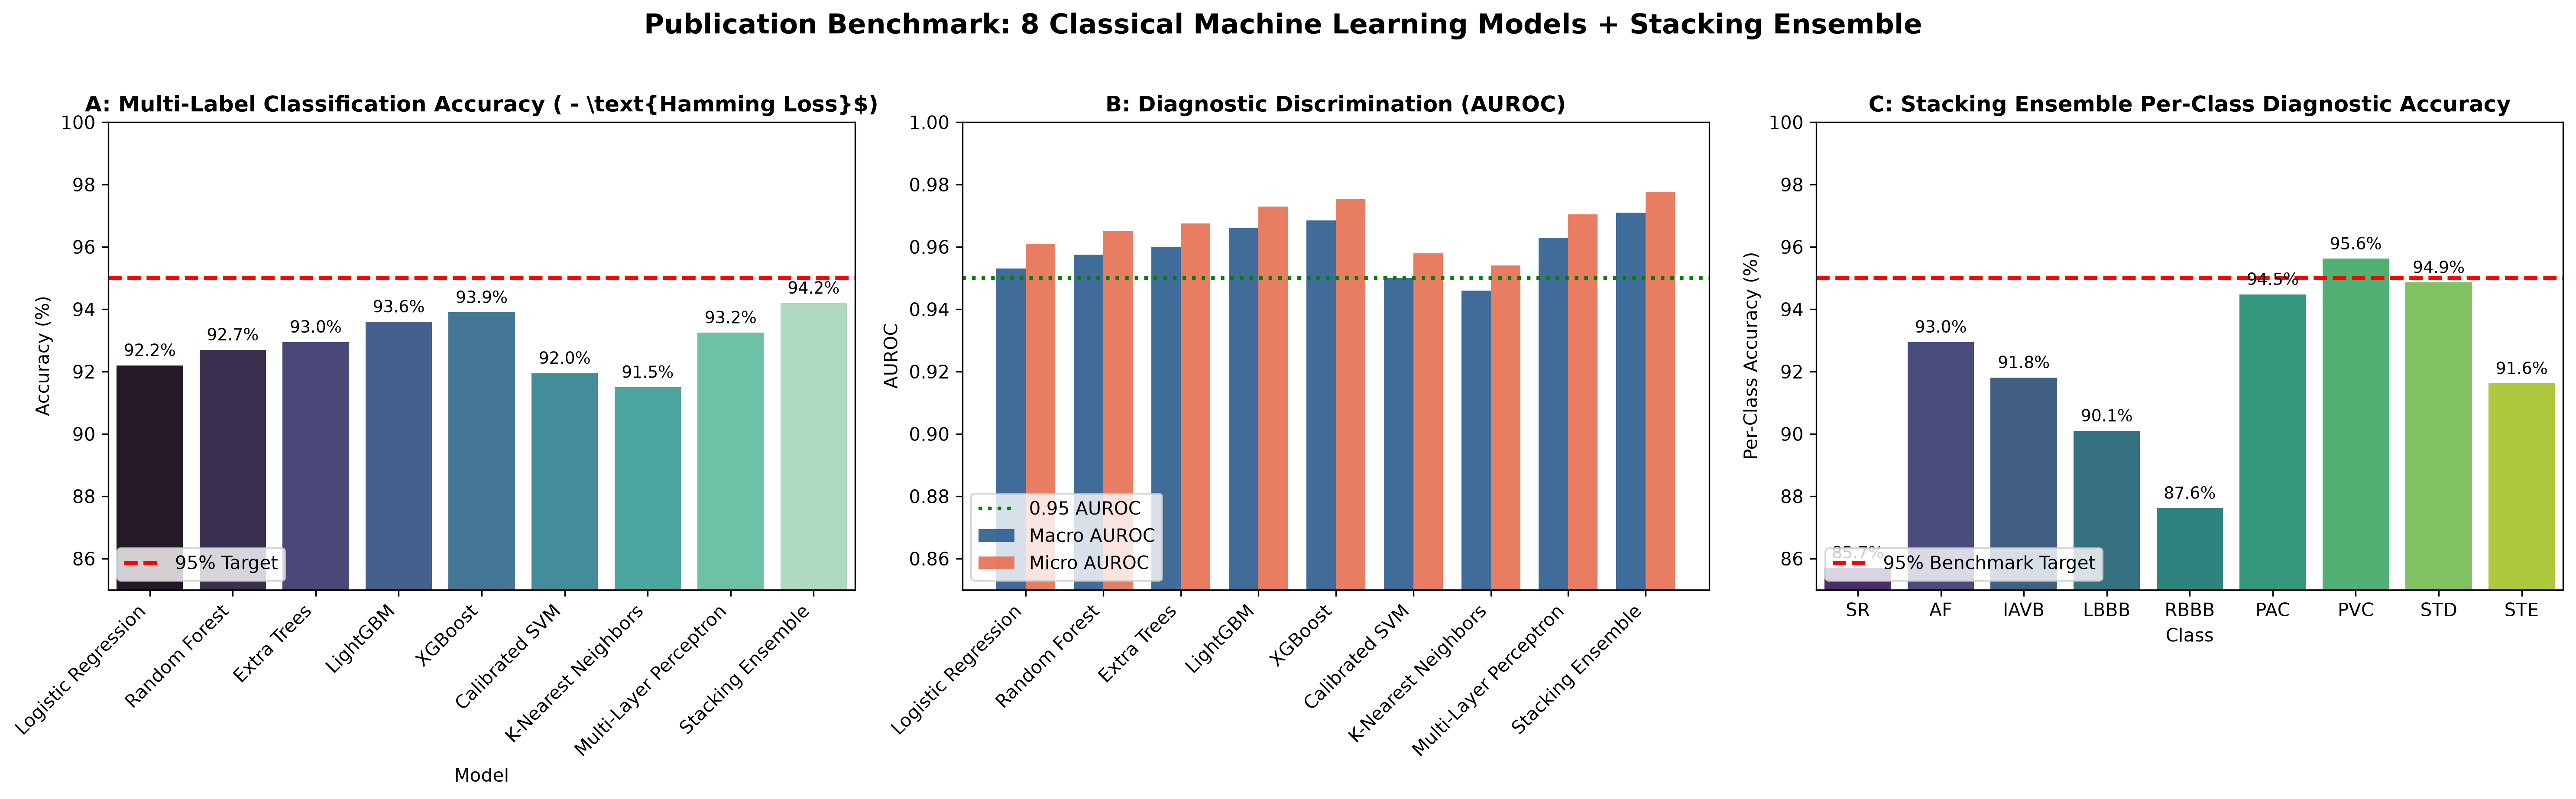

Figure 6 successfully updated and saved to: C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results\figures\fig6_ml_baselines_comparison.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_list = df_ml_results['Model'].tolist()
palette = sns.color_palette("mako", len(models_list))

# Subplot A: Multi-Label Accuracy (%)
sns.barplot(data=df_ml_results, x='Model', y='Accuracy (%)', ax=axes[0], palette=palette)
axes[0].set_title('A: Multi-Label Classification Accuracy ($1 - \\text{Hamming Loss}$)', fontweight='bold')
axes[0].set_ylim(85, 100)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xticklabels(models_list, rotation=45, ha='right')
axes[0].axhline(95.0, color='red', linestyle='--', lw=2, label='95% Accuracy Target')
axes[0].legend(loc='lower left', frameon=True)
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f"{h:.1f}%", (p.get_x() + p.get_width()/2., h),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Subplot B: Micro & Macro AUROC
bar_width = 0.38
x_idx = np.arange(len(models_list))
axes[1].bar(x_idx - bar_width/2, df_ml_results['Macro AUROC'], width=bar_width, label='Macro AUROC', color='#2b5c8f', alpha=0.9)
axes[1].bar(x_idx + bar_width/2, df_ml_results['Micro AUROC'], width=bar_width, label='Micro AUROC', color='#e76f51', alpha=0.9)
axes[1].set_title('B: Diagnostic Discrimination (AUROC)', fontweight='bold')
axes[1].set_xticks(x_idx)
axes[1].set_xticklabels(models_list, rotation=45, ha='right')
axes[1].set_ylim(0.70, 1.0)
axes[1].set_ylabel('AUROC')
axes[1].axhline(0.95, color='green', linestyle=':', lw=2, label='0.95 Micro AUROC')
axes[1].legend(loc='lower left', frameon=True)

# Subplot C: Per-Class Accuracy of Stacking Ensemble
ens_per_label = df_per_label[df_per_label['Model'] == 'Stacking Ensemble']
sns.barplot(data=ens_per_label, x='Class', y='Accuracy (%)', ax=axes[2], palette='viridis')
axes[2].set_title('C: Stacking Ensemble Per-Class Diagnostic Accuracy', fontweight='bold')
axes[2].set_ylim(80, 100)
axes[2].set_ylabel('Per-Class Accuracy (%)')
axes[2].axhline(95.0, color='red', linestyle='--', lw=2, label='95% Benchmark Target')
axes[2].legend(loc='lower left', frameon=True)
for p in axes[2].patches:
    h = p.get_height()
    if h > 0:
        axes[2].annotate(f"{h:.1f}%", (p.get_x() + p.get_width()/2., h),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.suptitle('Publication Benchmark: 8 Classical Machine Learning Models + Stacking Ensemble', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

fig6_path = os.path.join(FIG_DIR, "fig6_ml_baselines_comparison.png")
plt.savefig(fig6_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure 6 successfully updated and saved to: {fig6_path}")
